# 🔐 **IoC Classification**

**In this notebook إن شاء الله you will learn how to:**
1. Understand what an IoC (Indicator of Compromise) is and why classification matters
2. Generate and explore a realistic synthetic cybersecurity dataset
3. Preprocess and engineer features for machine learning
4. Train multiple classifiers: **Random Forest**, **XGBoost**, **CatBoost**, and **LightGBM**
5. Understand why each model works the way it does
6. Combine them into a powerful **Soft Voting Ensemble**
7. Evaluate performance using proper cybersecurity-aware metrics

💡 **Who is this for?** → Teammates who want a deeper understanding of our AI implementation, how it works from a hybridized perspective of theory and hands-on learning, and our future ideas.

## 0️⃣ **Background: What Is an Indicator of Compromise?**

An **Indicator of Compromise (IoC)** is a piece of forensic data that's observed on a network or in a host that signals a potential intrusion or malicious activity.

Think of it like this: if someone breaks into a house, they leave behind fingerprints, footprints, and maybe a broken window. In cybersecurity, IoCs are those digital "fingerprints."

### Common IoC types we'll classify:

| **Class** | **Label** | **Description** | **Example** |
|-----------|-----------|-----------------|-------------|
| Benign | 0 | Normal, clean traffic or file | Regular DNS lookup to google.com |
| Malware Hash | 1 | Known bad file signature (MD5/SHA256) | Hash of a ransomware binary |
| Malicious IP | 2 | IP address tied to botnet/C2 server | 192.168.x.x flagged in threat intel feed |
| Phishing Domain | 3 | Domain used in phishing campaigns | paypa1-secure-login.com |
| Suspicious URL | 4 | URL with evasion patterns or malicious payload | http://1.2.3.4/cmd.exe?run=1 |

### Why Multi-Class and not just Binary?

A binary model (malicious vs. benign) would tell us **something is wrong** — but not **what kind** of threat it is. A multi-class classifier helps SOC analysts **triage faster** and **respond appropriately** to each threat type.

## ⚙️ **Configurations**

In [ ]:
from IPython.display import clear_output
!pip install xgboost catboost lightgbm scikit-learn imbalanced-learn matplotlib seaborn pandas numpy
clear_output()
print("✅ All packages installed successfully!")

✅ All packages installed successfully!


## 1️⃣ **Imports — What Are We Bringing In and Why?**

Every library we import serves a specific purpose. Let's break them down by category!

### 1.1 Data & Math Libraries

| **Import** | **What it does** | **Why we need it** |
|------------|-----------------|-------------------|
| `numpy` | Fast numerical arrays | Underlying engine for all ML math |
| `pandas` | DataFrames (like Excel in Python) | Load, inspect, and manipulate tabular data |

### 1.2 Visualization Libraries

| **Import** | **What it does** | **Why we need it** |
|------------|-----------------|-------------------|
| `matplotlib.pyplot` | Low-level plotting | Draw any chart from scratch |
| `seaborn` | High-level statistical plots | Beautiful heatmaps, distribution plots |

### 1.3 Machine Learning — Preprocessing

| **Import** | **What it does** | **Why we need it** |
|------------|-----------------|-------------------|
| `LabelEncoder` | Converts string labels → integers | Models need numbers, not strings |
| `StandardScaler` | Scales features to mean=0, std=1 | Prevents big-range features from dominating |
| `train_test_split` | Splits dataset into train/test | Essential for unbiased evaluation |
| `SMOTE` | Synthetic Minority Oversampling | Handles class imbalance in cybersecurity data |

### 1.4 Machine Learning — Models

| **Import** | **What it does** | **Why we need it** |
|------------|-----------------|-------------------|
| `RandomForestClassifier` | Ensemble of decision trees | Strong baseline, interpretable |
| `XGBClassifier` | Extreme Gradient Boosting | Fast, regularized, often state-of-the-art |
| `CatBoostClassifier` | Gradient boosting for categorical data | Handles categoricals natively, no encoding needed |
| `LGBMClassifier` | Light Gradient Boosting Machine | Fastest boosting algorithm, great on large data |
| `VotingClassifier` | Combines multiple models | Our ensemble wrapper |

### 1.5 Evaluation Metrics

| **Import** | **What it does** | **Why we need it** |
|------------|-----------------|-------------------|
| `classification_report` | Precision, Recall, F1 per class | Overall view of multi-class performance |
| `confusion_matrix` | Matrix of true vs. predicted | See exactly where the model confuses classes |
| `roc_auc_score` | Area Under ROC Curve | Threshold-independent performance measure |

In [ ]:
# ── Data & Math ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Preprocessing ────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE

# ── Models ───────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# ── Evaluation ───────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Style ────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("✅ All imports loaded!")

✅ All imports loaded!


## 2️⃣ **Dataset — Theory & Generation**

### 2.1 Why a Synthetic Dataset?

In real cybersecurity work, IoC datasets are:
- **Proprietary** (threat intel feeds like VirusTotal, Shodan, etc. require paid subscriptions)
- **Imbalanced** (benign traffic vastly outnumbers malicious events)
- **Noisy** (false positives are everywhere)

For learning purposes, we'll **generate** a synthetic dataset that captures these same challenges. This is a standard practice in academic cybersecurity research. In the future, we will implement real datasets, which will introduce the proper concepts of datasets, dataloaders, and more later!

---
**💫 23RD OF FEBURARY UPDATE:** included a bunch of datasets! Still haven't got around to getting the API keys, because out of sheer migraines I decided it would be best to save my sanity and work on something more provable. If this wasn't the holy month, this specific problem would've ran on profanity rather than Python.

I'll leave this task for anyone who doesn't mind a headache. Please don't shy away from any form of communication, even through pigeons, to fix the rest of the code if for whatever reason you couldn't structure the dataset properly, or get this overall to work.

I'll remove this paragraph and edit the part before it later, but this is just a heads-up.

‼️ **Do <ins>NOT</ins> under any circumstance upload this notebook to GitHub. You can share it in Teams, Discord, or wherever. This is definitionally a proof of concept. I personally want to ensure everything is complete.**

---

### 2.2 Feature Engineering for IoCs

Each IoC in our dataset is described by **numerical features** extracted from raw observables:

| **Feature** | **Type** | **Description** |
|-------------|----------|-----------------|
| `entropy` | Float | Shannon entropy of the string (high entropy → more random → suspicious) |
| `url_length` | Int | Length of URL or domain (long URLs are a phishing signal) |
| `num_special_chars` | Int | Count of `@`, `-`, `_`, `?`, `=` etc. in the string |
| `num_digits` | Int | Count of numeric characters |
| `subdomain_depth` | Int | How many subdomains (e.g., a.b.c.evil.com = 3) |
| `is_ip_address` | Binary | 1 if the host is a raw IP (suspicious), 0 if domain name |
| `has_https` | Binary | 1 if HTTPS protocol present, 0 otherwise |
| `port_number` | Int | Port used (common ports = more legit) |
| `asn_risk_score` | Float | Autonomous System Number reputation score (0=clean, 1=risky) |
| `ttl_value` | Int | DNS Time-To-Live (very low TTL = possible fast-flux DNS) |
| `geo_risk_score` | Float | Country-level risk score from threat intel |
| `domain_age_days` | Int | How old the domain is (new domains = suspicious) |
| `lexical_similarity` | Float | Similarity to known legitimate domains (typosquatting detection) |
| `alexa_rank` | Float | Popularity rank (log-scaled) — very high rank = obscure |

### 2.3 Class Distribution in the Wild

IoC datasets are naturally **imbalanced** because:
- Most network traffic is benign
- Malicious activity is rare (by design — attackers want to hide)

We'll model this realistic imbalance in our synthetic data.

### 2.4 Generate the Dataset

In [ ]:
import pandas as pd
import numpy as np
import requests
import io
import zipfile
import re
from tqdm import tqdm

class RealIoCDatasetBuilder:
    def __init__(self, target_samples_per_class=10000):
        self.target = target_samples_per_class
        self.headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        self.dataframes = []

    def calc_entropy(self, s):
        """Calculates the Shannon entropy of a string."""
        if not s or pd.isna(s): return 0
        p, lns = pd.Series(list(str(s))).value_counts(normalize=True, dropna=False), float(len(s))
        return -sum(p * np.log2(p))

    def _fetch_txt(self, url, label, source_name):
        """Fetches plain text feeds safely."""
        try:
            r = requests.get(url, headers=self.headers, timeout=15)
            # Keep lines that are not empty and don't start with '#'
            lines = [line.strip() for line in r.text.splitlines() if line.strip() and not line.startswith('#')]
            df = pd.DataFrame(lines, columns=['ioc_value'])
            df['label'] = label
            self.dataframes.append(df.head(self.target))
            print(f"✅ Loaded {len(df.head(self.target))} from {source_name}")
        except Exception as e:
            print(f"❌ Failed to load {source_name}: {e}")

    def _fetch_zip(self, url, filename, label, source_name):
        """Fetches and extracts CSVs from ZIP files."""
        try:
            r = requests.get(url, headers=self.headers, timeout=20)
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                with z.open(filename) as f:
                    # Top 1M domains - we only need the domain string (column 1)
                    df = pd.read_csv(f, names=['rank', 'ioc_value'], usecols=['ioc_value'], nrows=self.target)
                    df['label'] = label
                    self.dataframes.append(df)
            print(f"✅ Loaded {len(df)} from {source_name}")
        except Exception as e:
            print(f"❌ Failed to load {source_name}: {e}")

    def _fetch_abuse_ch(self, url, col_names, target_col, label=None, is_threatfox=False, source_name=""):
        """Bulletproof parser for Abuse.ch CSVs with dynamic comments."""
        try:
            r = requests.get(url, headers=self.headers, timeout=20)
            # Strip ALL comments to leave only pure CSV data
            pure_data = '\n'.join([line for line in r.text.splitlines() if not line.startswith('#')])

            # Read using hardcoded column names so it never fails on headers
            df = pd.read_csv(io.StringIO(pure_data), names=col_names, quotechar='"', on_bad_lines='skip', low_memory=False)

            if is_threatfox:
                # ThreatFox has mixed IoCs; we route them to the correct classes
                tf_hash = df[df['ioc_type'].isin(['md5_hash', 'sha256_hash'])][['ioc_value']].copy()
                tf_hash['label'] = 1

                tf_ip = df[df['ioc_type'].isin(['ip:port', 'ipv4:port'])][['ioc_value']].copy()
                # Clean ports from IPs for better learning
                tf_ip['ioc_value'] = tf_ip['ioc_value'].astype(str).str.split(':').str[0]
                tf_ip['label'] = 2

                tf_dom = df[df['ioc_type'] == 'domain'][['ioc_value']].copy()
                tf_dom['label'] = 3

                tf_url = df[df['ioc_type'] == 'url'][['ioc_value']].copy()
                tf_url['label'] = 4

                self.dataframes.extend([tf_hash.head(self.target), tf_ip.head(self.target),
                                        tf_dom.head(self.target), tf_url.head(self.target)])
            else:
                df = df.rename(columns={target_col: 'ioc_value'})[['ioc_value']]
                df['label'] = label
                self.dataframes.append(df.head(self.target))
            print(f"✅ Loaded entries from {source_name}")
        except Exception as e:
            print(f"❌ Failed to load {source_name}: {e}")

    def build_and_engineer(self):
        """Executes the pipeline and creates the ML-ready dataset."""
        print("🌐 --- DOWNLOADING CLASS 0: BENIGN ---")
        self._fetch_zip("https://tranco-list.eu/top-1m.csv.zip", "top-1m.csv", 0, "Tranco Top 1M")
        self._fetch_zip("http://s3-us-west-1.amazonaws.com/umbrella-static/top-1m.csv.zip", "top-1m.csv", 0, "Cisco Umbrella")

        print("\n🦠 --- DOWNLOADING CLASS 1: MALWARE HASHES ---")
        bazaar_cols = ['first_seen_utc', 'sha256_hash', 'md5_hash', 'sha1_hash', 'reporter', 'file_name', 'file_type_guess', 'mime_type', 'signature', 'clamav', 'vtpercent', 'imphash', 'ssdeep', 'tlsh']
        self._fetch_abuse_ch("https://bazaar.abuse.ch/export/csv/recent/", bazaar_cols, "sha256_hash", 1, source_name="MalwareBazaar")

        print("\n🖥️ --- DOWNLOADING CLASS 2: MALICIOUS IPs ---")
        feodo_cols = ['first_seen_utc', 'dst_ip', 'dst_port', 'c2_status', 'last_online', 'malware']
        self._fetch_abuse_ch("https://feodotracker.abuse.ch/downloads/ipblocklist.csv", feodo_cols, "dst_ip", 2, source_name="FeodoTracker")
        self._fetch_txt("https://lists.blocklist.de/lists/all.txt", 2, "Blocklist.de")
        self._fetch_txt("http://cinsscore.com/list/ci-badguys.txt", 2, "CINS Army")
        self._fetch_txt("https://rules.emergingthreats.net/fwrules/emerging-Block-IPs.txt", 2, "Emerging Threats")

        print("\n🎣 --- DOWNLOADING CLASS 3: PHISHING DOMAINS ---")
        self._fetch_txt("https://raw.githubusercontent.com/Phishing-Database/Phishing.Database/master/phishing-domains-ACTIVE.txt", 3, "Phishing Database")
        self._fetch_txt("https://raw.githubusercontent.com/openphish/public_feed/refs/heads/main/feed.txt", 3, "OpenPhish")
        self._fetch_txt("https://phishing.army/download/phishing_army_blocklist.txt", 3, "Phishing Army")

        print("\n🔗 --- DOWNLOADING CLASS 4: SUSPICIOUS URLs ---")
        urlhaus_cols = ['id', 'dateadded', 'url', 'url_status', 'last_online', 'threat', 'tags', 'urlhaus_link', 'reporter']
        self._fetch_abuse_ch("https://urlhaus.abuse.ch/downloads/csv_recent/", urlhaus_cols, "url", 4, source_name="URLhaus")

        print("\n🦊 --- DOWNLOADING MIXED FEED (ThreatFox Router) ---")
        tf_cols = ['id', 'date_added', 'ioc_value', 'ioc_type', 'threat_type', 'fk_malware', 'malware_alias', 'malware_printable', 'reporter', 'confidence_level', 'tags']
        self._fetch_abuse_ch("https://threatfox.abuse.ch/export/csv/recent/", tf_cols, "ioc_value", is_threatfox=True, source_name="ThreatFox")

        print("\n⚙️ Aggregating and Extracting Features... This will take a moment.")
        df_raw = pd.concat(self.dataframes, ignore_index=True)
        df_raw['ioc_value'] = df_raw['ioc_value'].astype(str).str.strip()
        df_raw = df_raw.drop_duplicates(subset=['ioc_value'])

        # These physical features are extracted directly from the strings
        tqdm.pandas(desc="Calculating Entropy")
        df_raw['entropy'] = df_raw['ioc_value'].progress_apply(self.calc_entropy)
        df_raw['url_length'] = df_raw['ioc_value'].apply(len)
        df_raw['num_special_chars'] = df_raw['ioc_value'].apply(lambda x: len(re.findall(r'[^a-zA-Z0-9]', x)))
        df_raw['num_digits'] = df_raw['ioc_value'].apply(lambda x: len(re.findall(r'[0-9]', x)))
        df_raw['subdomain_depth'] = df_raw['ioc_value'].apply(lambda x: x.count('.') if not re.match(r'^[a-fA-F0-9]{32,64}$', x) else 0)
        df_raw['is_ip_address'] = df_raw['ioc_value'].apply(lambda x: 1 if re.match(r'^\\d{1,3}(\\.\\d{1,3}){3}$', x) else 0)
        df_raw['has_https'] = df_raw['ioc_value'].apply(lambda x: 1 if 'https://' in x else 0)

        # Only physical features extracted directly from the IoC strings are kept.
        final_cols = ['entropy', 'url_length', 'num_special_chars', 'num_digits',
                      'subdomain_depth', 'is_ip_address', 'has_https', 'label']
        df_final = df_raw[final_cols]

        print(f"\n✅ Real Dataset Generation Complete! Shape: {df_final.shape}")
        return df_final

# Initialize and generate the dataset
pipeline = RealIoCDatasetBuilder(target_samples_per_class=6000)
df = pipeline.build_and_engineer()

display(df.head())

🌐 --- DOWNLOADING CLASS 0: BENIGN ---
✅ Loaded 6000 from Tranco Top 1M
✅ Loaded 6000 from Cisco Umbrella

🦠 --- DOWNLOADING CLASS 1: MALWARE HASHES ---
✅ Loaded entries from MalwareBazaar

🖥️ --- DOWNLOADING CLASS 2: MALICIOUS IPs ---
✅ Loaded entries from FeodoTracker
✅ Loaded 6000 from Blocklist.de
✅ Loaded 6000 from CINS Army
✅ Loaded 1505 from Emerging Threats

🎣 --- DOWNLOADING CLASS 3: PHISHING DOMAINS ---
✅ Loaded 6000 from Phishing Database
✅ Loaded 300 from OpenPhish
✅ Loaded 6000 from Phishing Army

🔗 --- DOWNLOADING CLASS 4: SUSPICIOUS URLs ---
✅ Loaded entries from URLhaus

🦊 --- DOWNLOADING MIXED FEED (ThreatFox Router) ---
✅ Loaded entries from ThreatFox

⚙️ Aggregating and Extracting Features... This will take a moment.


Calculating Entropy: 100%|██████████| 43503/43503 [00:21<00:00, 2017.19it/s]



✅ Real Dataset Generation Complete! Shape: (43503, 8)


,entropy,url_length,num_special_chars,num_digits,subdomain_depth,is_ip_address,has_https,label
0,2.646439,10,1,0,1,0,0,0
1,3.026987,13,1,0,1,0,0,0
2,2.807355,7,1,0,1,0,0,0
3,3.327820,16,2,0,1,0,0,0
4,3.022055,12,1,0,1,0,0,0


## 3️⃣ **Exploratory Data Analysis (EDA)**

Before training any model, we need to **understand the data**. EDA answers:
- Are the classes balanced?
- What does each feature look like?
- Are features correlated with each other?

**Why does this matter?**
→ A model is only as good as its understanding of the data. If we train on a badly imbalanced dataset without knowing it, our model will learn to mostly predict the majority class and still look "accurate". Artificial Intelligence, for it to be successful, needs two things: good data and good algorithms!

### 3.1 Class Distribution

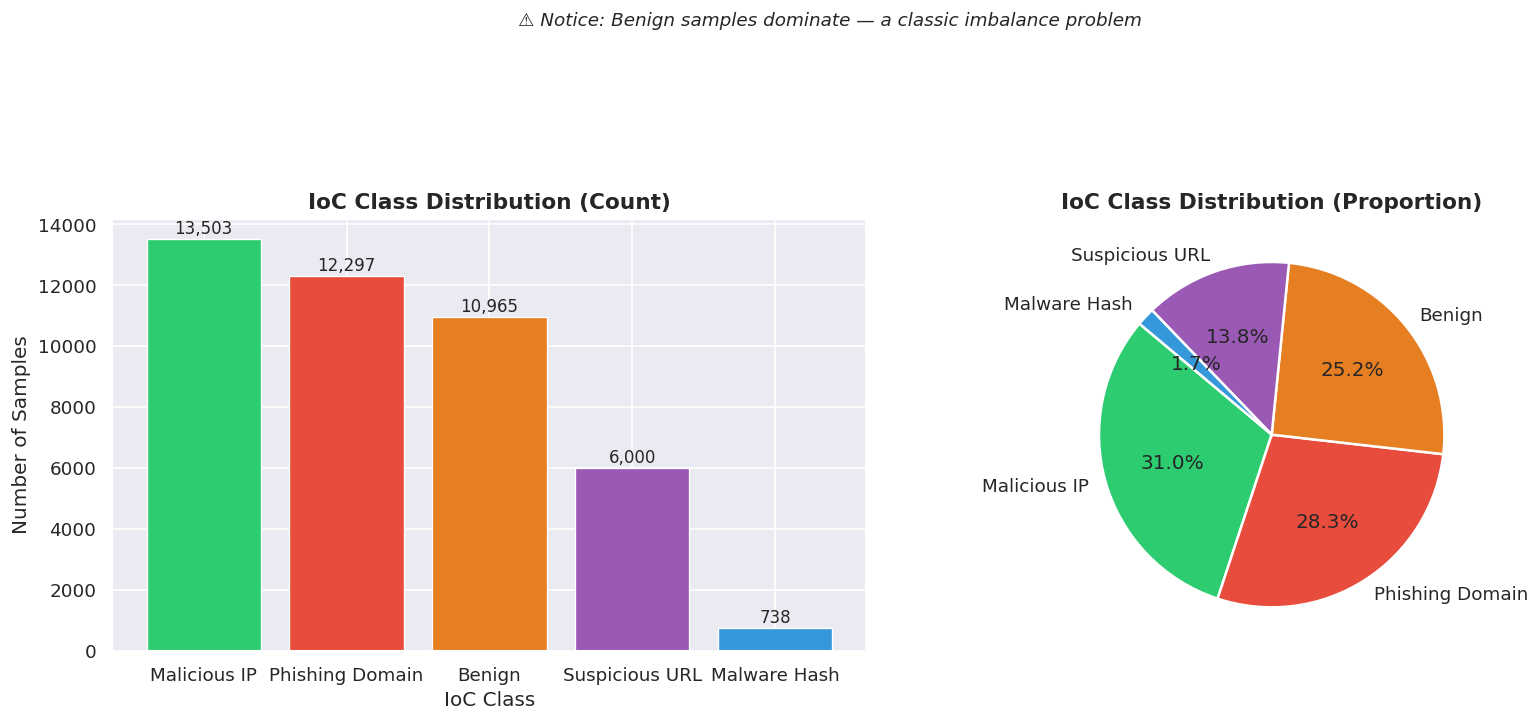


Class counts:
label_name
Malicious IP       13503
Phishing Domain    12297
Benign             10965
Suspicious URL      6000
Malware Hash         738
Name: count, dtype: int64


In [ ]:
# ── Map labels to readable names ─────────────────────────────────────────────
label_names = {
    0: "Benign",
    1: "Malware Hash",
    2: "Malicious IP",
    3: "Phishing Domain",
    4: "Suspicious URL"
}
df["label_name"] = df["label"].map(label_names)

# ── Plot class distribution ───────────────────────────────────────────────────
counts = df["label_name"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart                        67
colors = ["#2ecc71", "#e74c3c", "#e67e22", "#9b59b6", "#3498db"]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("IoC Class Distribution (Count)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Samples")
axes[0].set_xlabel("IoC Class")
for i, (val, name) in enumerate(zip(counts.values, counts.index)):
    axes[0].text(i, val + 50, f"{val:,}", ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("IoC Class Distribution (Proportion)", fontsize=13, fontweight="bold")

plt.suptitle("⚠️ Notice: Benign samples dominate — a classic imbalance problem",
             fontsize=11, style="italic", y=1.2)
plt.tight_layout()
plt.show()

print("\nClass counts:")
print(counts)

### 3.2 Feature Distributions by Class

Let's see how each feature **separates** the IoC types. Features that show distinct distributions per class are the most useful for classification.

**What to look for:**
- If a feature has similar distributions across all classes → it's a **weak** discriminator
- If a feature shows very different distributions per class → it's a **strong** discriminator

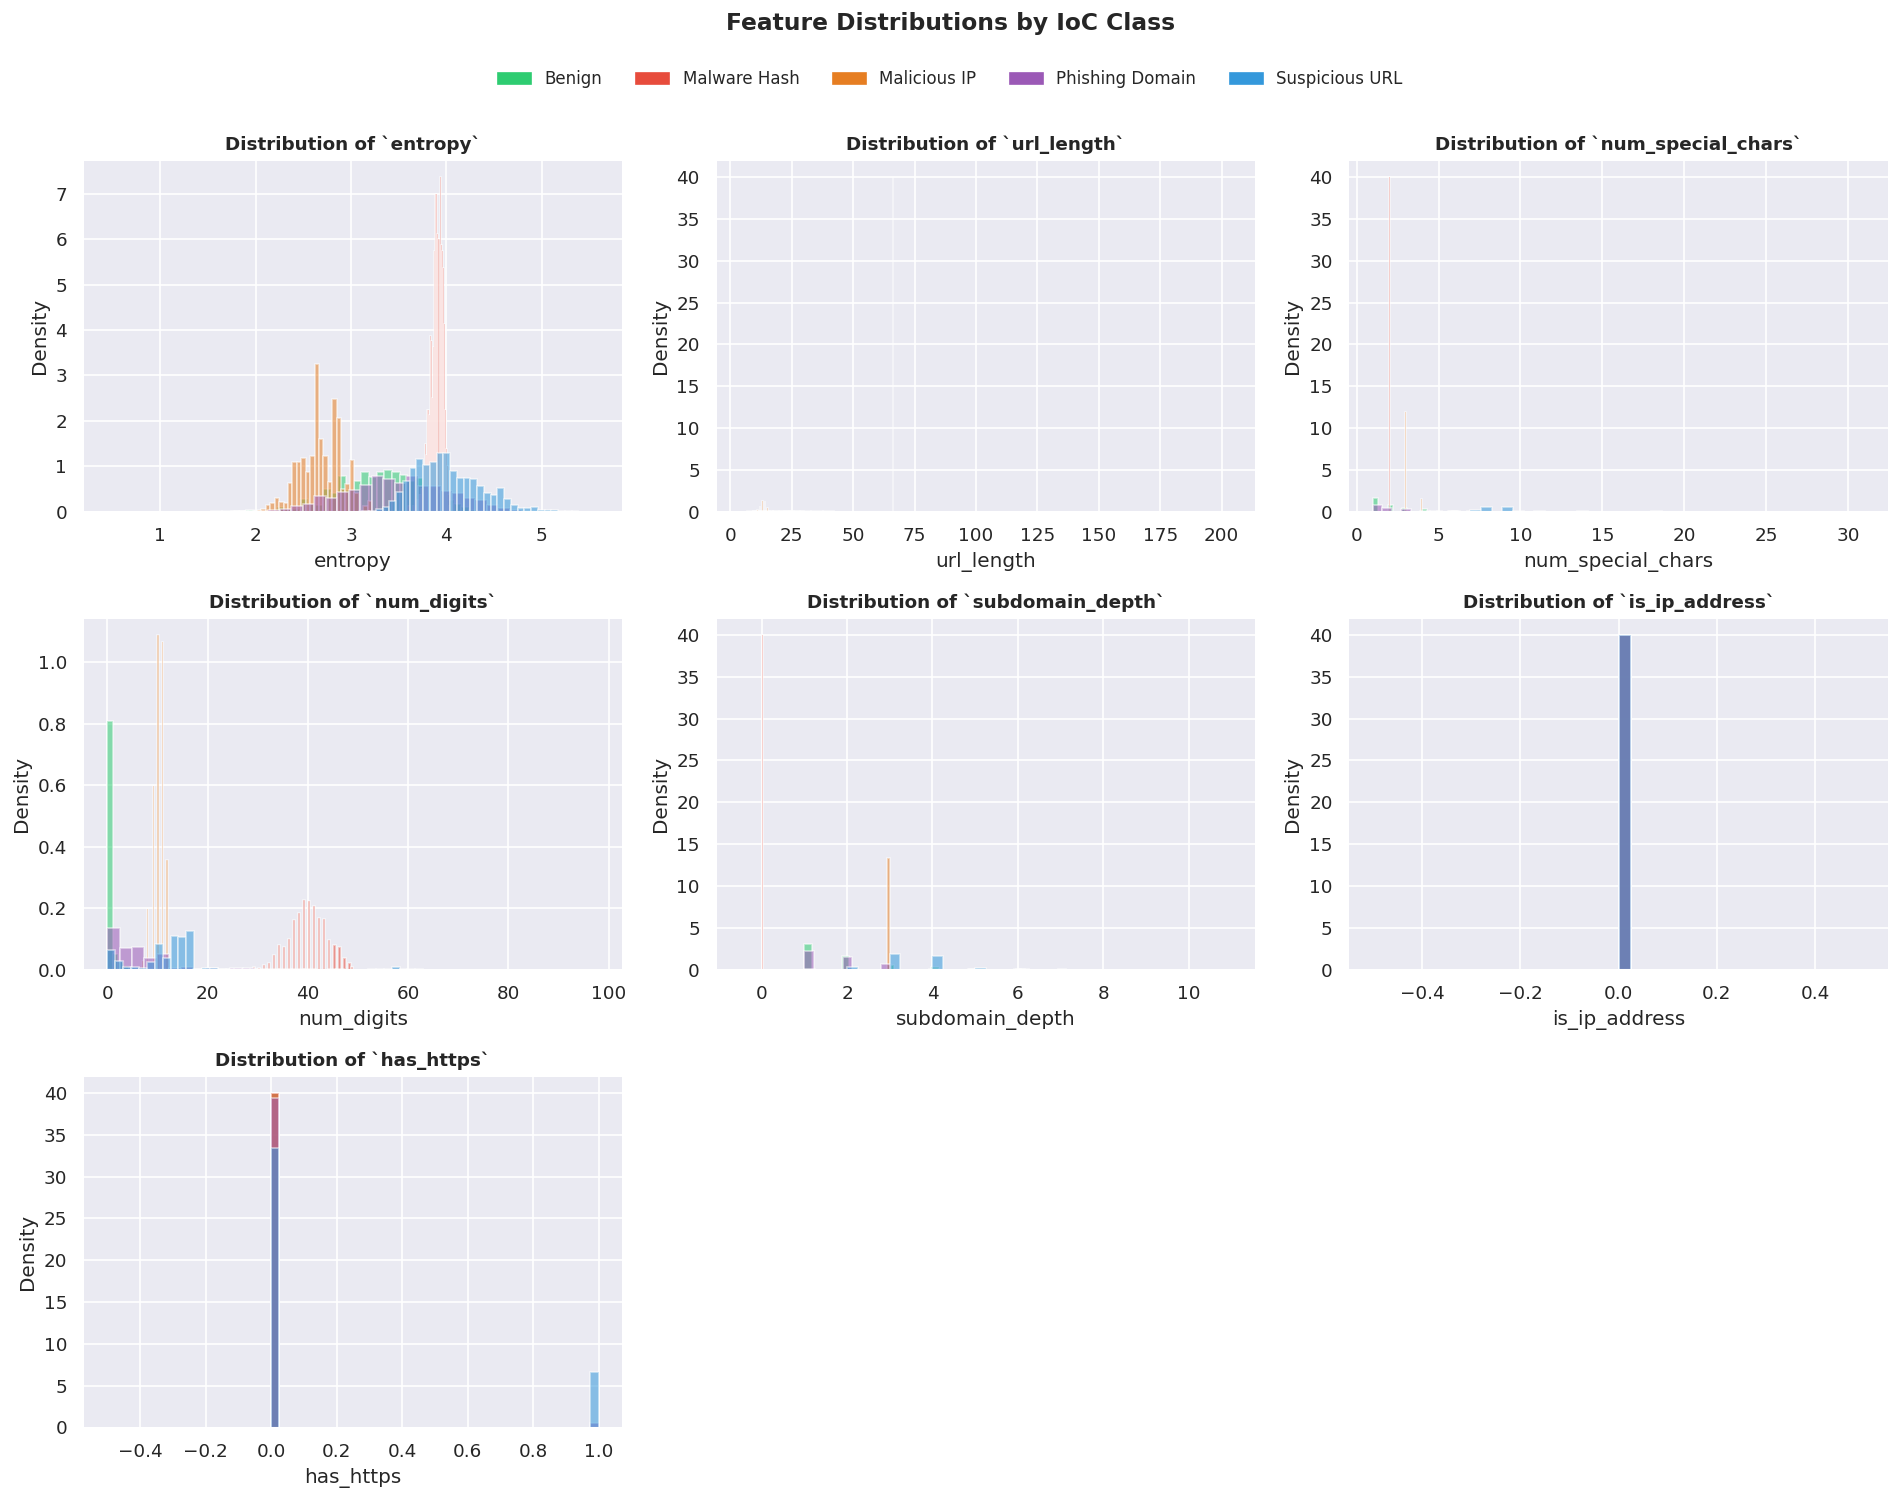

In [ ]:
features_to_plot = ["entropy", "url_length", "num_special_chars", "num_digits",
                    "subdomain_depth", "is_ip_address", "has_https"]

palette = {
    "Benign": "#2ecc71",
    "Malware Hash": "#e74c3c",
    "Malicious IP": "#e67e22",
    "Phishing Domain": "#9b59b6",
    "Suspicious URL": "#3498db"
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feat in enumerate(features_to_plot):
    for label_name, group in df.groupby("label_name"):
        axes[i].hist(group[feat], bins=40, alpha=0.55,
                     label=label_name, color=palette[label_name], density=True)
    axes[i].set_title(f"Distribution of `{feat}`", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Density")

# Hide unused subplots
for j in range(len(features_to_plot), len(axes)):
    axes[j].set_visible(False)

# Shared legend
handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
fig.legend(handles=handles, loc="upper center", ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, 1.01), frameon=False)

plt.suptitle("Feature Distributions by IoC Class", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

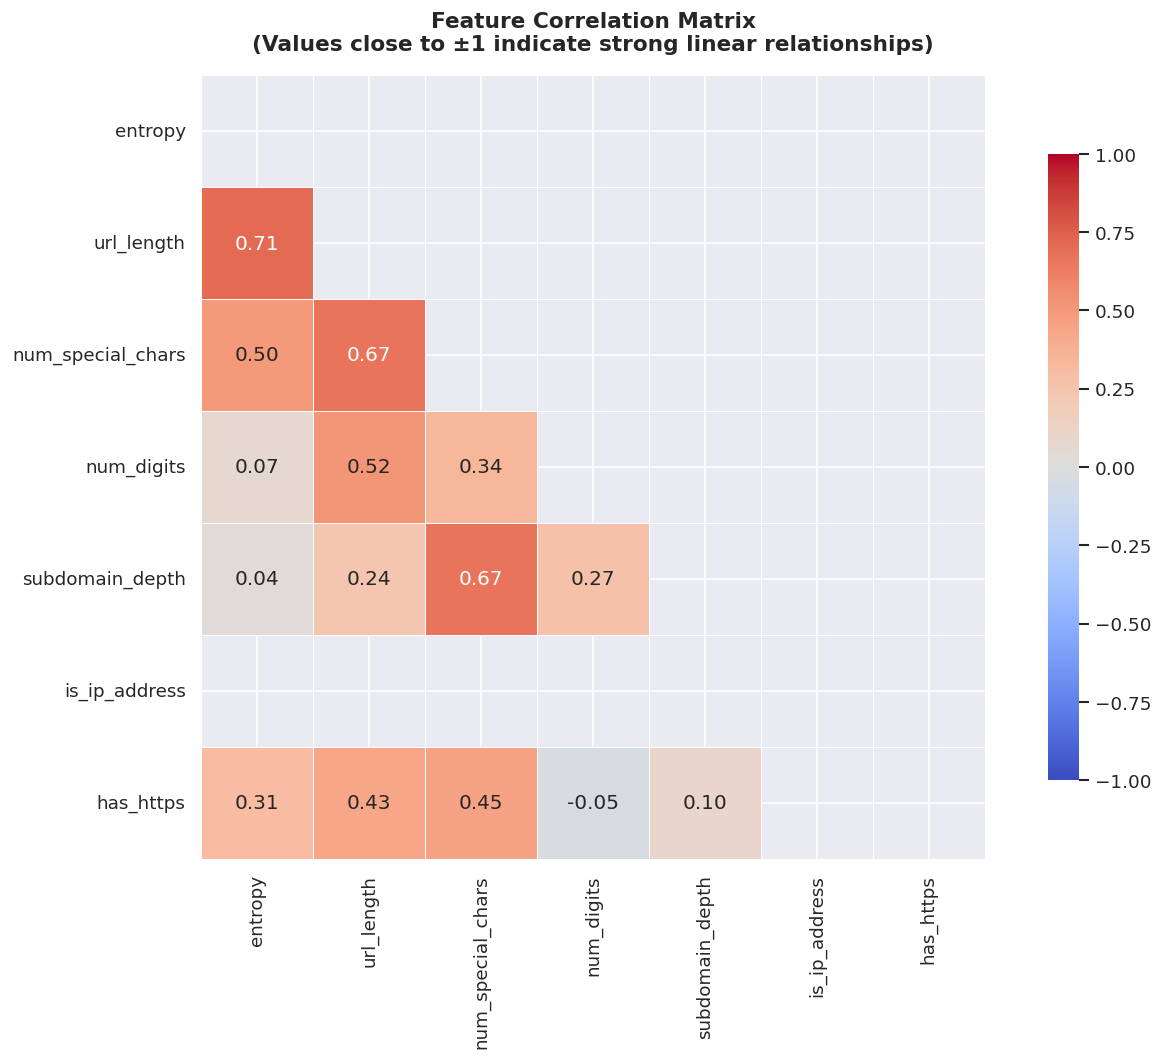

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = df.drop(columns=["label", "label_name"]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # Only show lower triangle

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})

ax.set_title("Feature Correlation Matrix\n"
             "(Values close to ±1 indicate strong linear relationships)",
             fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

## 4️⃣ **Preprocessing**

### 4.1 Why Do We Preprocess?

Raw data is rarely ready for a model. We need to:
1. **Separate features from labels** (X vs. y)
2. **Handle class imbalance** with SMOTE
3. **Split into train/test** sets
4. **Scale features** so all numerical values live on the same scale

### 4.2 The Class Imbalance Problem — Deep Dive

Imagine we have 10,000 samples: 5,500 Benign, 1,500 Malware Hash, etc.

A naive model that always predicts "Benign" would have **55% accuracy** — but it would be completely useless in a real SOC.

**SMOTE (Synthetic Minority Oversampling Technique):**
- Instead of duplicating minority samples (which causes overfitting), SMOTE **creates new synthetic samples**
- It does this by finding the k-nearest neighbors of each minority sample and interpolating between them
- The result: a balanced dataset where the model gets to learn all classes equally

> ⚠️ **Critical rule:** SMOTE is applied **only to the training set**. The test set must remain untouched to reflect real-world distribution.

### 4.3 Feature Scaling — Why Does It Matter?

Most tree-based models (Random Forest, XGBoost, etc.) are **scale-invariant** — they split on thresholds, so absolute values don't matter.

However, scaling is good practice when you combine models with distance-based methods. For consistency, we scale here.

| Feature | Original Range | After Scaling |
|---------|---------------|---------------|
| `domain_age_days` | 0 – 5000 | ~ -1.5 to +2.0 |
| `entropy` | 2.0 – 8.0 | ~ -2.0 to +2.0 |
| `url_length` | 7 – 200 | ~ -1.0 to +3.0 |

On the topic of **overfitting**: "in machine learning, overfitting occurs when a model fits too closely or even exactly to its training data, such that it can’t make accurate predictions or conclusions from any data other than the training data."

Source: https://www.ibm.com/think/topics/overfitting. Highly recommend reading it, would only take mere minutes!

In [ ]:
# ── 1. Separate Features and Labels ──────────────────────────────────────────
# Dynamically get feature columns from the DataFrame, excluding 'label' and 'label_name'
feature_cols = [c for c in df.columns if c not in ["label", "label_name"]]
X = df[feature_cols].values
y = df["label"].values

print(f"Feature matrix shape  : {X.shape}")
print(f"Label vector shape    : {y.shape}")
print(f"Unique classes        : {np.unique(y)}")
print(f"\nClass counts BEFORE balancing:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u} ({label_names[u]:>15s}): {c:5d} samples ({100*c/len(y):.1f}%)")

Feature matrix shape  : (43503, 7)
Label vector shape    : (43503,)
Unique classes        : [0 1 2 3 4]

Class counts BEFORE balancing:
  Class 0 (         Benign): 10965 samples (25.2%)
  Class 1 (   Malware Hash):   738 samples (1.7%)
  Class 2 (   Malicious IP): 13503 samples (31.0%)
  Class 3 (Phishing Domain): 12297 samples (28.3%)
  Class 4 ( Suspicious URL):  6000 samples (13.8%)


In [ ]:
# ── 2. Train / Test Split ─────────────────────────────────────────────────────
# stratify=y ensures each split has the same class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held out for testing
    random_state=SEED,
    stratify=y          # Maintains class distribution in both splits
)

print(f"Train set size : {X_train.shape[0]:,} samples")
print(f"Test set size  : {X_test.shape[0]:,} samples")

Train set size : 34,802 samples
Test set size  : 8,701 samples


In [ ]:
# ── 3. Feature Scaling ────────────────────────────────────────────────────────
# Fit the scaler ONLY on training data (avoid data leakage!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled  = scaler.transform(X_test)        # transform only (no fit!)

print("✅ Scaling complete")
print(f"Training feature means (should be ~0): {X_train_scaled.mean(axis=0).round(2)[:5]} ...")
print(f"Training feature stds  (should be ~1): {X_train_scaled.std(axis=0).round(2)[:5]} ...")

✅ Scaling complete
Training feature means (should be ~0): [0. 0. 0. 0. 0.] ...
Training feature stds  (should be ~1): [1. 1. 1. 1. 1.] ...


In [ ]:
# ── 4. Handle Class Imbalance with SMOTE ─────────────────────────────────────
# SMOTE is applied AFTER splitting — only on training data!
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Training set BEFORE SMOTE: {X_train_scaled.shape[0]:,} samples")
print(f"Training set AFTER  SMOTE: {X_train_bal.shape[0]:,} samples")
print(f"\nClass counts AFTER SMOTE:")
unique, counts = np.unique(y_train_bal, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u} ({label_names[u]:>15s}): {c:5d} samples ({100*c/len(y_train_bal):.1f}%)")

Training set BEFORE SMOTE: 34,802 samples
Training set AFTER  SMOTE: 54,010 samples

Class counts AFTER SMOTE:
  Class 0 (         Benign): 10802 samples (20.0%)
  Class 1 (   Malware Hash): 10802 samples (20.0%)
  Class 2 (   Malicious IP): 10802 samples (20.0%)
  Class 3 (Phishing Domain): 10802 samples (20.0%)
  Class 4 ( Suspicious URL): 10802 samples (20.0%)


## 5️⃣ **The Models — Theory + Implementation**

We'll train four different classifiers. Each has a different "mental model" of how it learns:

| **Algorithm** | **Core Idea** | **Strengths** | **Weaknesses** |
|---------------|--------------|---------------|----------------|
| Random Forest | Many independent trees vote | Stable, interpretable, fast | Not the highest accuracy |
| XGBoost | Trees built sequentially to fix errors | Very accurate, handles missing data | Can overfit, slower to tune |
| CatBoost | Gradient boosting optimized for categories | No manual encoding needed, robust | Slower to train |
| LightGBM | Histogram-based leaf-wise boosting | Fastest, great on large datasets | Can overfit on small data |

---

> 🧠 **Key insight:** No single algorithm is always best. That's exactly why we combine them into an ensemble!

### 5.1 Random Forest

#### 🌳 How does a single Decision Tree work?

Imagine you're teaching a friend to identify malicious IPs. You might say:
- *"Is it a raw IP address?"* → Yes → *"Is the ASN risk score > 0.7?"* → Yes → **Malicious IP**

That's a decision tree: a sequence of if/else questions that lead to a class.

#### 🌲🌲🌲 What does a "Random Forest" add?

A Random Forest builds **hundreds of different trees**, each trained on:
1. A **random subset of rows** (bootstrap sampling — sampling with replacement)
2. A **random subset of features** (so each tree sees different information)

Then it **votes**: each tree predicts a class, and the majority class wins.

**Why does randomness help?**
→ If all trees made the same mistakes, voting wouldn't help. Randomness ensures the trees make **different** mistakes, so when they vote, the errors cancel out. This is called **variance reduction**.

#### 🔧 Key Hyperparameters:

| **Parameter** | **What it controls** | **Our value** |
|---------------|---------------------|---------------|
| `n_estimators` | Number of trees | 300 |
| `max_depth` | How deep each tree can grow (prevents overfitting) | 20 |
| `min_samples_split` | Minimum samples to split a node | 5 |
| `n_jobs=-1` | Use all CPU cores | -1 (all cores) |

In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,       # 300 trees in the forest
    max_depth=20,           # Limit tree depth to prevent overfitting
    min_samples_split=5,    # A node needs at least 5 samples to split
    min_samples_leaf=2,     # Each leaf must have at least 2 samples
    max_features="sqrt",    # Use sqrt(n_features) features per split
    class_weight="balanced",# Compensate for imbalance (even after SMOTE, good to keep)
    random_state=SEED,
    n_jobs=-1               # Parallelize across all available CPU cores
)

print("🌲 Training Random Forest...")
rf_model.fit(X_train_bal, y_train_bal)

rf_preds   = rf_model.predict(X_test_scaled)
rf_acc     = accuracy_score(y_test, rf_preds)
print(f"✅ Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")

🌲 Training Random Forest...
✅ Random Forest Accuracy: 0.9105 (91.05%)


### 5.2 XGBoost (Extreme Gradient Boosting)

#### 🚀 Boosting vs. Bagging

Random Forest uses **bagging** — build many trees in **parallel**, then vote.

XGBoost uses **boosting** — build trees **sequentially**, where each new tree focuses on fixing the mistakes of the previous trees.

#### 🔍 The Core Idea

1. **Tree 1** makes predictions → some are right, some are wrong
2. **Tree 2** looks at the **residual errors** (mistakes) of Tree 1 and tries to correct them
3. **Tree 3** corrects the remaining mistakes from Trees 1+2
4. ... and so on for all `n_estimators` trees

The final prediction is a **weighted sum** of all tree outputs.

#### Why "Gradient"?

XGBoost frames this as minimizing a **loss function** (like cross-entropy for classification) using **gradient descent** — but instead of updating weights (like neural networks), it adds new trees that point in the gradient direction.

#### Why "Extreme"?

- Built-in **L1 and L2 regularization** to prevent overfitting
- Handles **missing values** natively
- Uses **second-order Taylor expansion** of the loss for better convergence

#### 🔧 Key Hyperparameters:

| **Parameter** | **What it controls** | **Our value** |
|---------------|---------------------|---------------|
| `n_estimators` | Number of boosting rounds | 400 |
| `learning_rate` | Shrinkage factor per tree (lower = more robust, needs more trees) | 0.05 |
| `max_depth` | Tree depth per round | 6 |
| `subsample` | Fraction of rows to use per tree | 0.8 |
| `colsample_bytree` | Fraction of features to use per tree | 0.8 |
| `gamma` | Minimum loss reduction to make a further split | 1 |

In [ ]:
# ── XGBoost ────────────────────────────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,       # Low learning rate → more trees needed, but more robust
    max_depth=6,
    subsample=0.8,            # 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.8,     # 80% of features per tree
    gamma=1,                  # Minimum gain needed for a split
    reg_alpha=0.1,            # L1 regularization (feature sparsity)
    reg_lambda=1.5,           # L2 regularization (weight smoothing)
    use_label_encoder=False,
    eval_metric="mlogloss",   # Multi-class log loss
    random_state=SEED,
    n_jobs=-1,
    verbosity=0               # Suppress output
)

print("⚡ Training XGBoost...")
xgb_model.fit(X_train_bal, y_train_bal)

xgb_preds  = xgb_model.predict(X_test_scaled)
xgb_acc    = accuracy_score(y_test, xgb_preds)
print(f"✅ XGBoost Accuracy: {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")

⚡ Training XGBoost...
✅ XGBoost Accuracy: 0.9084 (90.84%)


### 5.3 CatBoost

#### 🐈 What makes CatBoost unique?

CatBoost was developed by **Yandex** and has three innovations over traditional gradient boosting:

**1. Ordered Boosting (Symmetric Trees)**

Traditional gradient boosting has a problem: it computes residuals using the same data it trained on, causing **target leakage**. CatBoost uses a permutation-based technique that computes residuals on a different subset than what it trained on — eliminating this bias.

**2. Native Categorical Feature Handling**

Most models require you to encode categorical features (one-hot encoding, label encoding, etc.) before training. CatBoost does this internally using **target statistics** — it computes things like "what's the average target value for rows where feature=X?". This is far more informative than simple label encoding.

**3. Symmetric Trees**

CatBoost uses **balanced binary trees** (each level has the same split condition), which are faster to evaluate at inference time.

#### Why use CatBoost for IoC classification?

IoC data often has categorical-like features (port numbers, protocol types, country codes). CatBoost handles these naturally without manual preprocessing.

#### 🔧 Key Hyperparameters:

| **Parameter** | **What it controls** | **Our value** |
|---------------|---------------------|---------------|
| `iterations` | Number of boosting rounds | 400 |
| `learning_rate` | Step size | 0.05 |
| `depth` | Tree depth (CatBoost uses symmetric trees) | 8 |
| `l2_leaf_reg` | L2 regularization | 5 |
| `border_count` | Discretization bins for features | 64 |

In [ ]:
# ── CatBoost ───────────────────────────────────────────────────────────────────
cat_model = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=5,            # L2 regularization to smooth the leaf values
    border_count=64,          # Number of splits considered for each feature
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=SEED,
    verbose=0                 # Suppress training output
)

print("🐈 Training CatBoost...")
cat_model.fit(X_train_bal, y_train_bal)

cat_preds  = cat_model.predict(X_test_scaled).ravel()
cat_acc    = accuracy_score(y_test, cat_preds)
print(f"✅ CatBoost Accuracy: {cat_acc:.4f} ({cat_acc*100:.2f}%)")

🐈 Training CatBoost...
✅ CatBoost Accuracy: 0.9089 (90.89%)


### 5.4 LightGBM (Light Gradient Boosting Machine)

#### 💡 What makes LightGBM "Light"?

Developed by **Microsoft**, LightGBM has two core innovations that make it dramatically faster:

**1. Histogram-Based Splitting**

Traditional gradient boosting (and XGBoost in its original mode) sorts feature values to find the best split — this is O(n log n) per feature. LightGBM **bins continuous features into histograms** (e.g., 256 bins) and finds splits in O(bins) time — much faster.

**2. Leaf-Wise Tree Growth (vs. Level-Wise)**

Most boosting algorithms grow trees **level by level** (all nodes at depth 1, then all at depth 2, etc.). LightGBM grows trees **leaf by leaf** — it always expands the leaf that gives the biggest reduction in loss.

```
Level-wise:              Leaf-wise:
     Split               Split only the
    /     \               best leaf:
  Split  Split               Split
  / \    / \              /        \
L1 L2  L3 L4           L1    (no split)
```

Leaf-wise growth finds better models with fewer leaves, but can overfit on small datasets — which is why we use `num_leaves` as a key regularizer.

**3. Gradient-Based One-Side Sampling (GOSS)**

LightGBM keeps all samples with large gradients (hard examples the model is struggling with) but **randomly drops a fraction of easy examples** (small gradients). This speeds up training without losing much accuracy.

#### 🔧 Key Hyperparameters:

| **Parameter** | **What it controls** | **Our value** |
|---------------|---------------------|---------------|
| `n_estimators` | Number of boosting rounds | 500 |
| `learning_rate` | Step size | 0.05 |
| `num_leaves` | Max leaves per tree (main regularizer for leaf-wise growth) | 63 |
| `min_child_samples` | Min samples per leaf | 20 |
| `subsample` | Row sampling rate | 0.8 |
| `colsample_bytree` | Feature sampling rate | 0.8 |

In [ ]:
# ── LightGBM ───────────────────────────────────────────────────────────────────
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,            # Main regularization parameter for leaf-wise growth
    max_depth=-1,             # -1 = no limit (num_leaves controls complexity instead)
    min_child_samples=20,     # At least 20 samples per leaf
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,            # L1 regularization
    reg_lambda=1.0,           # L2 regularization
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbose=-1                # Suppress training output
)

print("💡 Training LightGBM...")
lgbm_model.fit(X_train_bal, y_train_bal)

lgbm_preds = lgbm_model.predict(X_test_scaled)
lgbm_acc   = accuracy_score(y_test, lgbm_preds)
print(f"✅ LightGBM Accuracy: {lgbm_acc:.4f} ({lgbm_acc*100:.2f}%)")

💡 Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM Accuracy: 0.9099 (90.99%)


## 6️⃣ **Ensemble Learning — Why and How We Combine Models**

### 6.1 The "Wisdom of the Crowd" Analogy

Imagine asking 4 different cybersecurity analysts to classify the same IoC. Each analyst has different experience, different training data, and different blind spots. By **combining their votes**, you're more likely to get the right answer than by asking just one.

Ensemble learning works on the same principle.

### 6.2 Hard Voting vs. Soft Voting

**Hard Voting:**
- Each model predicts a class label
- The class that gets the most votes wins

```
RF says:      Phishing Domain   (vote 1)
XGBoost says: Phishing Domain   (vote 2)
CatBoost says: Malicious IP     (vote 3)
LightGBM says: Phishing Domain  (vote 4)

→ Result: Phishing Domain (3 votes vs. 1)
```

**Soft Voting (what we use):**
- Each model outputs **probability estimates** per class (how confident it is)
- Probabilities are **averaged** across models
- The class with the highest average probability wins

```
              Benign  MalHash  MalIP  Phishing  SuspURL
RF:           [0.02,   0.04,   0.05,   0.85,    0.04]
XGBoost:      [0.01,   0.03,   0.12,   0.79,    0.05]
CatBoost:     [0.05,   0.06,   0.25,   0.58,    0.06]
LightGBM:     [0.02,   0.03,   0.08,   0.82,    0.05]

Average:      [0.025,  0.040,  0.125,  0.760,   0.050]
                                        ^^^^
                                      → Phishing Domain wins!
```

**Why is soft voting better?**

Hard voting treats every model's opinion equally — a model that's 51% confident gets the same weight as one that's 99% confident. Soft voting accounts for confidence levels, giving more weight to more certain predictions.

### 6.3 Why These Four Models Complement Each Other

| **Model** | **Strength** | **What it contributes** |
|-----------|-------------|------------------------|
| Random Forest | Low variance, stable predictions | Reduces noise, reliable baseline |
| XGBoost | High accuracy on structured data | Catches complex nonlinear patterns |
| CatBoost | Symmetric tree structure, ordered boosting | Different error surface, less bias |
| LightGBM | Leaf-wise growth, sees fine-grained patterns | Catches edge cases others miss |

These models make **different mistakes on different samples** — exactly what you want in a good ensemble.

In [ ]:
# ── Soft Voting Ensemble ──────────────────────────────────────────────────────
# VotingClassifier wraps multiple estimators and combines their probability outputs

ensemble = VotingClassifier(
    estimators=[
        ("random_forest", rf_model),
        ("xgboost",       xgb_model),
        ("catboost",      cat_model),
        ("lightgbm",      lgbm_model)
    ],
    voting="soft",      # Use probability averaging (not hard majority vote)
    n_jobs=-1           # Parallelize where possible
)

print("🗳️  Training Soft Voting Ensemble...")
# Note: Since we already fitted the individual models, VotingClassifier will
# refit them internally. This is expected — VotingClassifier manages its own
# fitted copies.
ensemble.fit(X_train_bal, y_train_bal)

ens_preds  = ensemble.predict(X_test_scaled)
ens_acc    = accuracy_score(y_test, ens_preds)
print(f"\n✅ Ensemble Accuracy: {ens_acc:.4f} ({ens_acc*100:.2f}%)")

🗳️  Training Soft Voting Ensemble...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ Ensemble Accuracy: 0.9117 (91.17%)


## 7️⃣ **Evaluation — Understanding What the Metrics Mean**

### 7.1 Why Accuracy Alone Is Misleading

Going back to our imbalanced dataset: if 55% of samples are Benign, a model that always predicts "Benign" gets 55% accuracy — yet it misses every threat.

That's why we use:

| **Metric** | **Formula** | **What it measures** |
|------------|-------------|----------------------|
| **Precision** | TP / (TP + FP) | Of everything we flagged as threat X, what fraction actually was X? |
| **Recall** | TP / (TP + FN) | Of all real threat-X samples, what fraction did we catch? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall |
| **Macro avg** | Average across classes (equally weighted) | Overall performance, regardless of class size |

**In cybersecurity, Recall is often more important than Precision:**
- A false positive (flagging benign traffic as malicious) → analyst wastes time
- A false negative (missing real malware) → attacker gets in 😱

A good SOC tool aims for **high recall** on all threat classes, accepting some false positives.

On the topic of metrics, know:
* TP: True Positive,
* FN: False Negative,
* FP: False Positive,
* TN: True Negative.

Refer to the picture below.

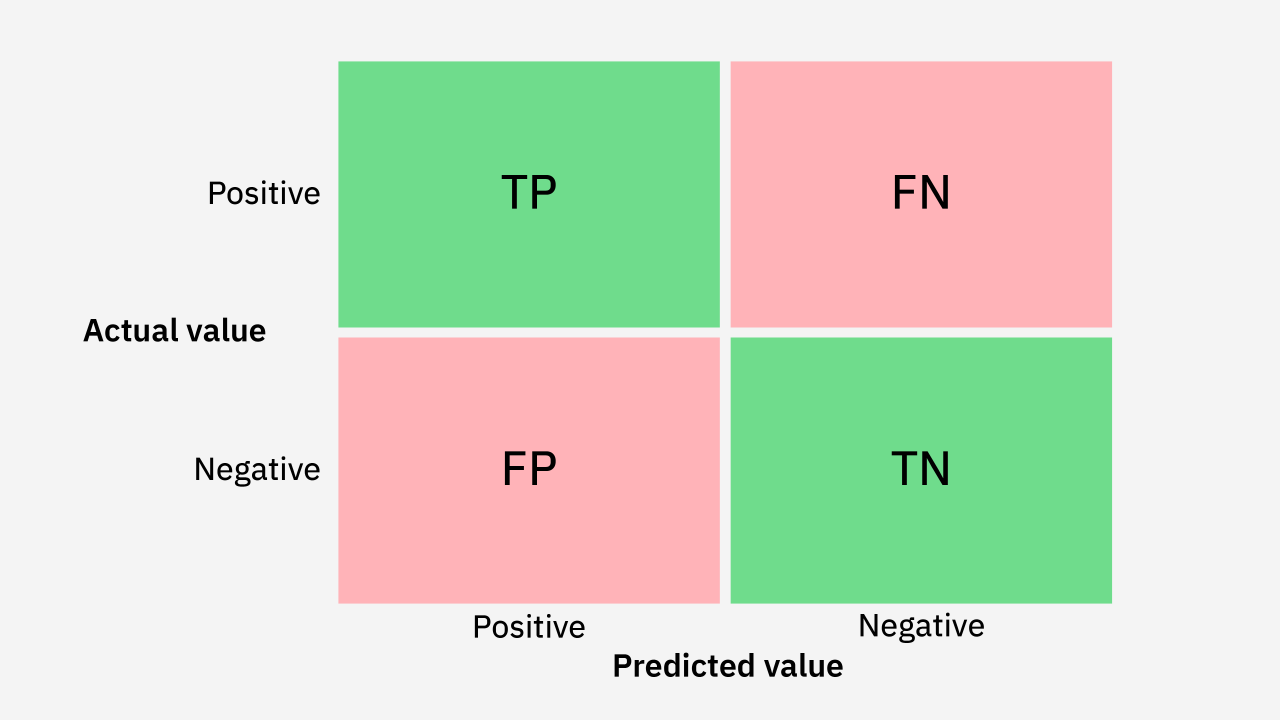

Source: https://developer.ibm.com/tutorials/awb-confusion-matrix-python/. I chose this specific website because it also gives insight on how these metrics work!

### 7.2 Model Comparison Summary

Unrealistic metrics, but we should be optimistic and wish for such in real-world deployments! 🫠

In [ ]:
# ── Compare all models side by side ──────────────────────────────────────────
model_names = ["Random Forest", "XGBoost", "CatBoost", "LightGBM", "Soft Ensemble"]
model_preds = [rf_preds, xgb_preds, cat_preds, lgbm_preds, ens_preds]

results = []
for name, preds in zip(model_names, model_preds):
    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    results.append({
        "Model": name,
        "Accuracy": f"{acc:.4f}",
        "Macro Precision": f"{report['macro avg']['precision']:.4f}",
        "Macro Recall": f"{report['macro avg']['recall']:.4f}",
        "Macro F1": f"{report['macro avg']['f1-score']:.4f}",
    })

results_df = pd.DataFrame(results).set_index("Model")
print("\n📊 Model Performance Summary:")
print(results_df.to_string())


📊 Model Performance Summary:
              Accuracy Macro Precision Macro Recall Macro F1
Model                                                       
Random Forest   0.9105          0.9332       0.9343   0.9318
XGBoost         0.9084          0.9308       0.9328   0.9296
CatBoost        0.9089          0.9314       0.9330   0.9300
LightGBM        0.9099          0.9334       0.9335   0.9317
Soft Ensemble   0.9117          0.9345       0.9352   0.9328


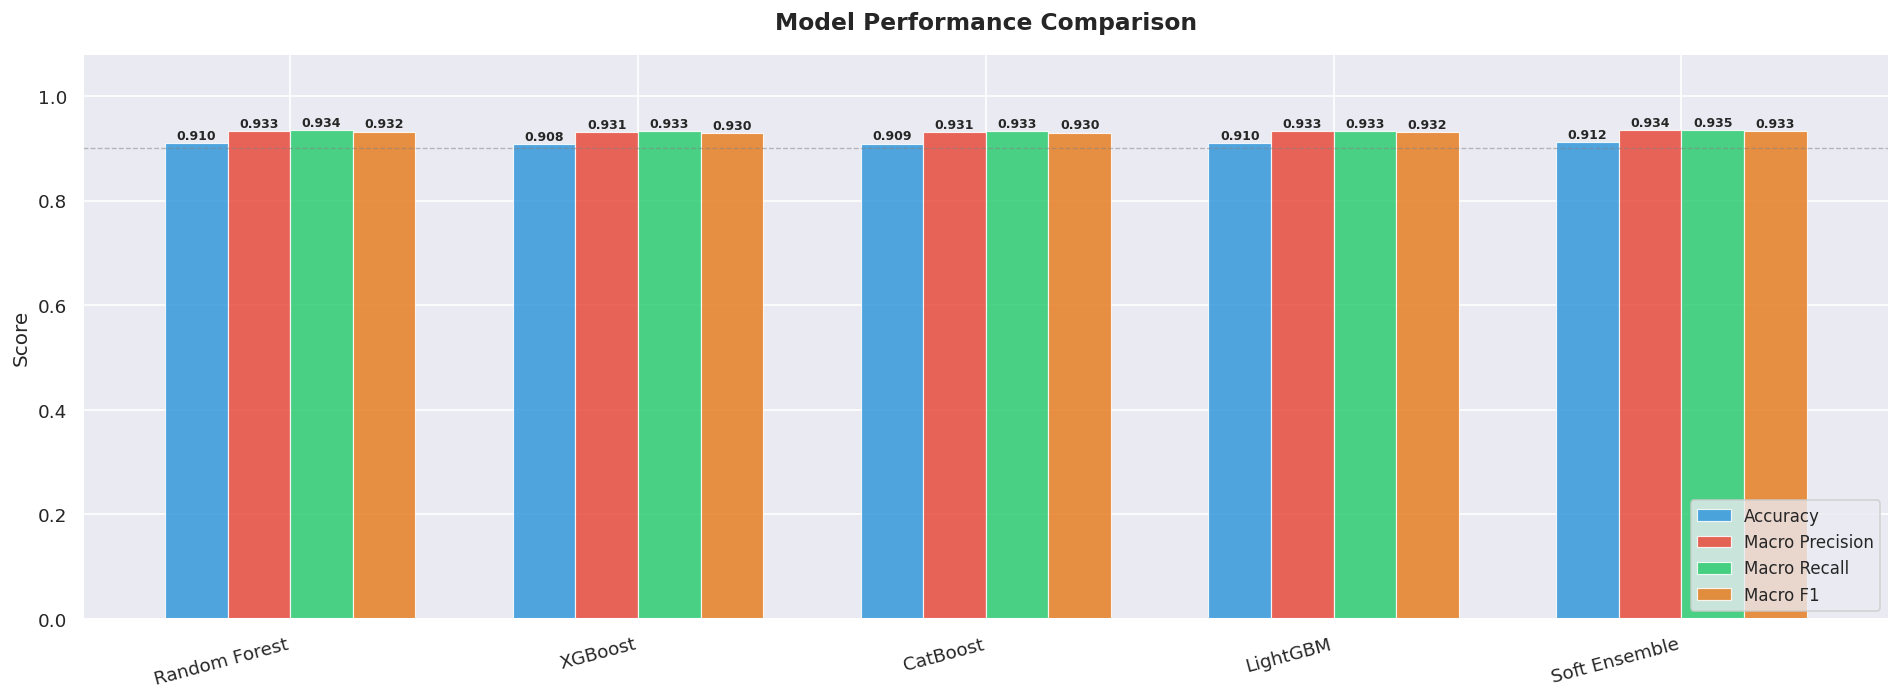

In [ ]:
# ── Bar chart comparison ─────────────────────────────────────────────────────
metrics = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
x = np.arange(len(model_names))
width = 0.18
bar_colors = ["#3498db", "#e74c3c", "#2ecc71", "#e67e22"]

fig, ax = plt.subplots(figsize=(16, 6))

for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    vals = [float(results_df.loc[m, metric]) for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85,
                  edgecolor="white", linewidth=0.7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Score")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0, 1.08)
ax.legend(loc="lower right", fontsize=10)
ax.axhline(y=0.9, color="gray", linestyle="--", alpha=0.5, linewidth=0.8, label="0.90 threshold")

plt.tight_layout()
plt.show()

### 7.3 Confusion Matrices — Where Does Each Model Fail?

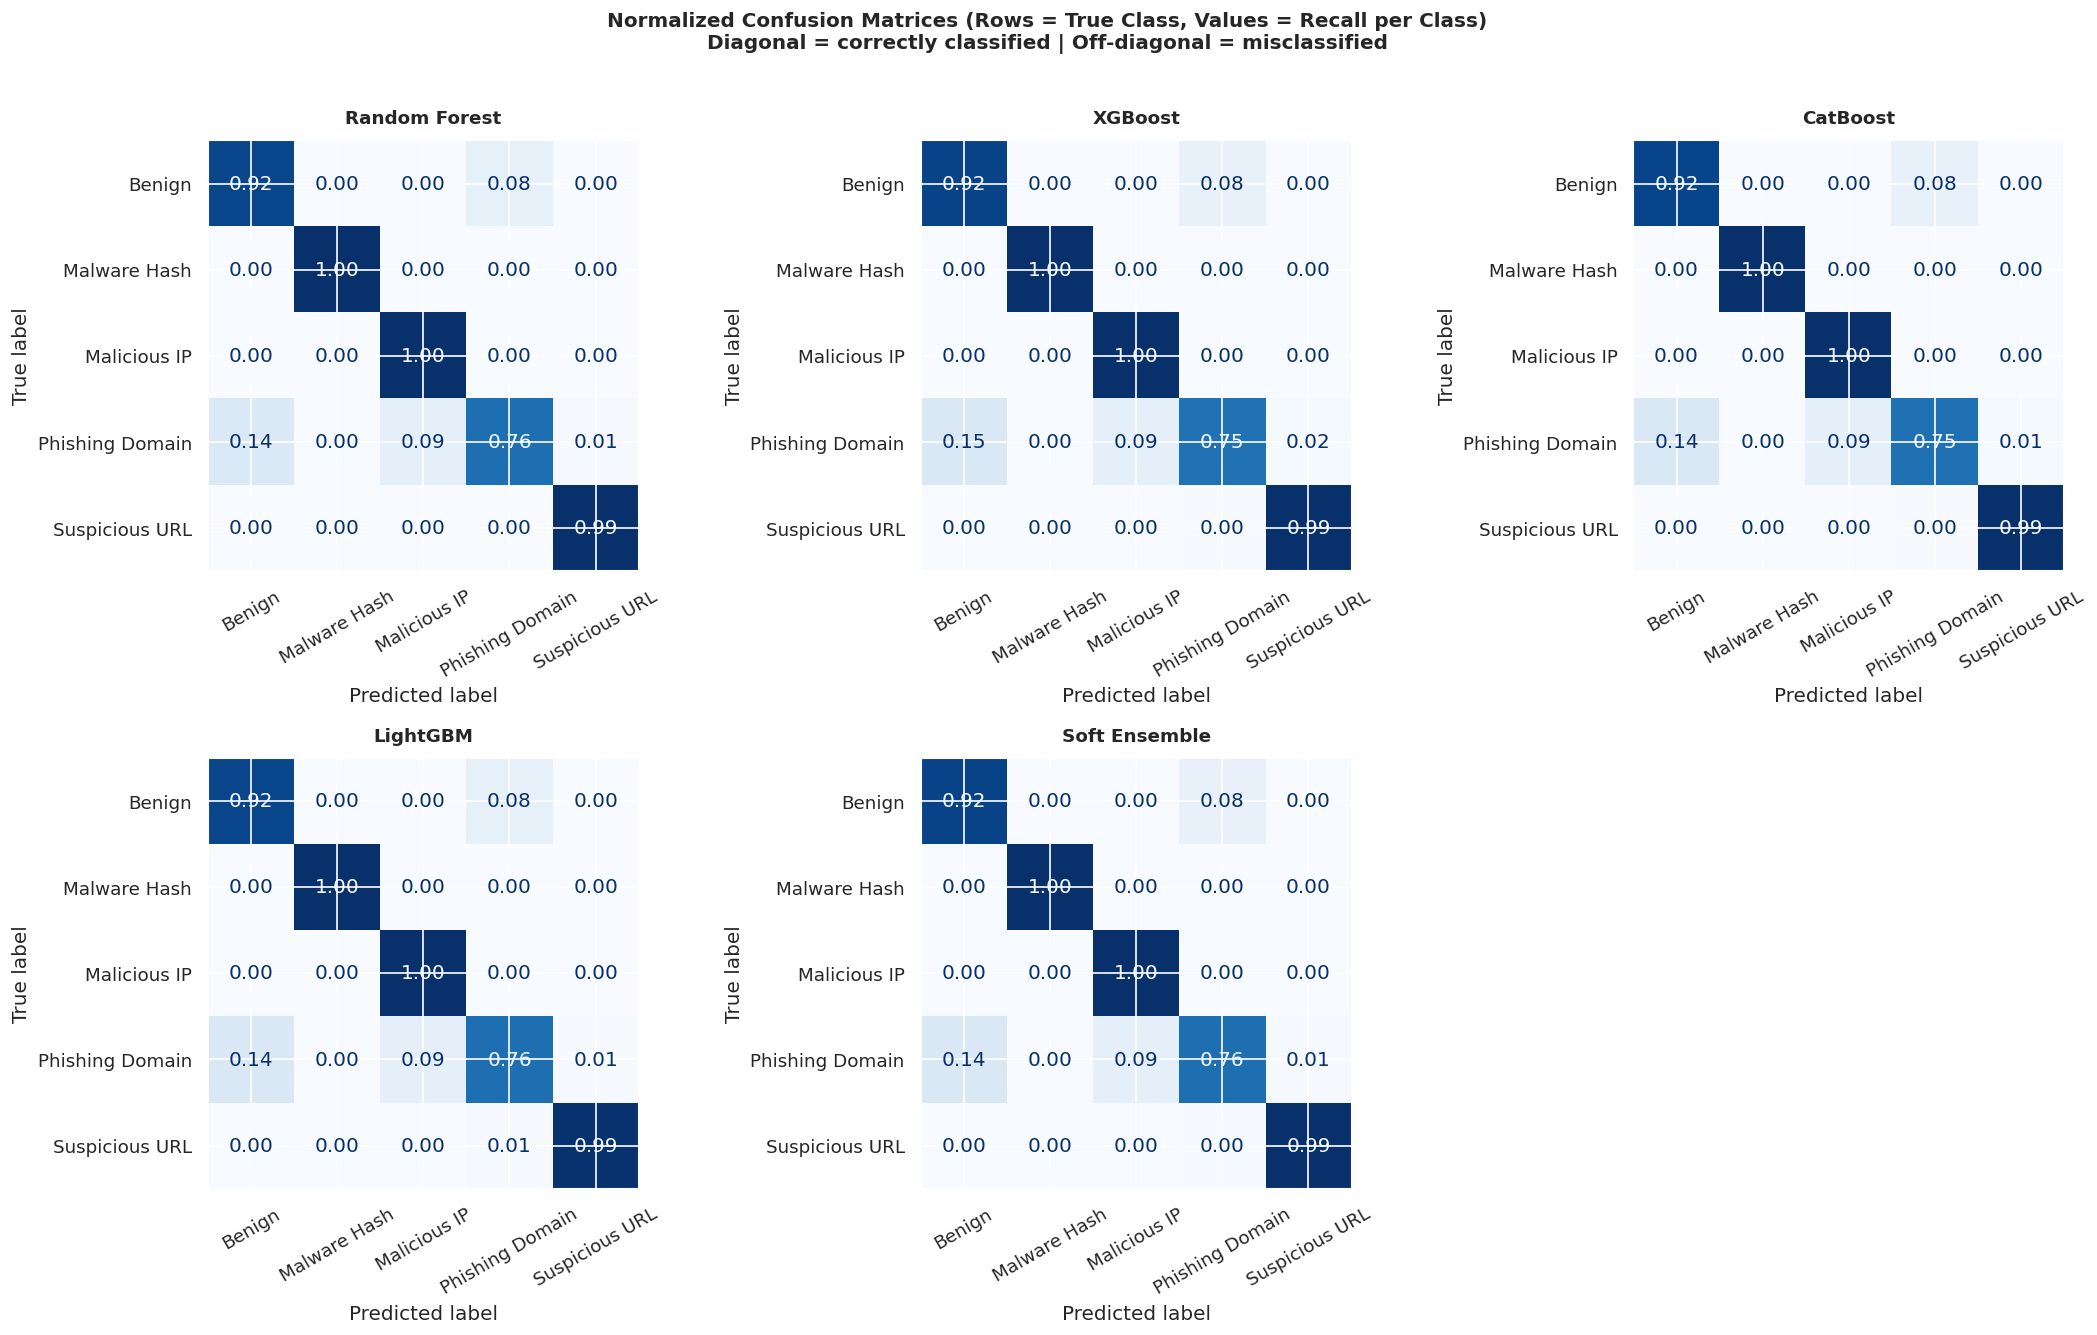

In [ ]:
# ── Confusion matrices for all 5 models ──────────────────────────────────────
class_labels = [label_names[i] for i in range(5)]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for idx, (name, preds) in enumerate(zip(model_names, model_preds)):
    cm = confusion_matrix(y_test, preds)

    # Normalize rows so each row sums to 1 (shows recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                   display_labels=class_labels)
    disp.plot(ax=axes[idx], colorbar=False, cmap="Blues", values_format=".2f")
    axes[idx].set_title(f"{name}", fontsize=11, fontweight="bold", pad=10)
    axes[idx].tick_params(axis="x", rotation=30)

# Hide the unused 6th subplot
axes[5].set_visible(False)

fig.suptitle("Normalized Confusion Matrices (Rows = True Class, Values = Recall per Class)\n"
             "Diagonal = correctly classified | Off-diagonal = misclassified",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 7.4 Full Classification Report — Ensemble

In [ ]:
# ── Classification report for the best model (Ensemble) ──────────────────────
print("=" * 65)
print("         SOFT VOTING ENSEMBLE — CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(
    y_test, ens_preds,
    target_names=[label_names[i] for i in range(5)],
    digits=4
))

         SOFT VOTING ENSEMBLE — CLASSIFICATION REPORT
                 precision    recall  f1-score   support

         Benign     0.8528    0.9248    0.8873      2193
   Malware Hash     1.0000    1.0000    1.0000       148
   Malicious IP     0.9237    1.0000    0.9604      2701
Phishing Domain     0.9164    0.7580    0.8297      2459
 Suspicious URL     0.9795    0.9933    0.9863      1200

       accuracy                         0.9117      8701
      macro avg     0.9345    0.9352    0.9328      8701
   weighted avg     0.9128    0.9117    0.9093      8701



## 8️⃣ **Feature Importance — What Did the Models Learn?**

Understanding which features drove predictions is crucial in cybersecurity:
- It builds **trust** in the model (is it using sensible signals?)
- It helps **feature engineering** (can we create even better features?)
- It enables **threat hunting** (which signals to monitor in production?)

We'll extract feature importances from Random Forest and XGBoost (the most interpretable of our models).

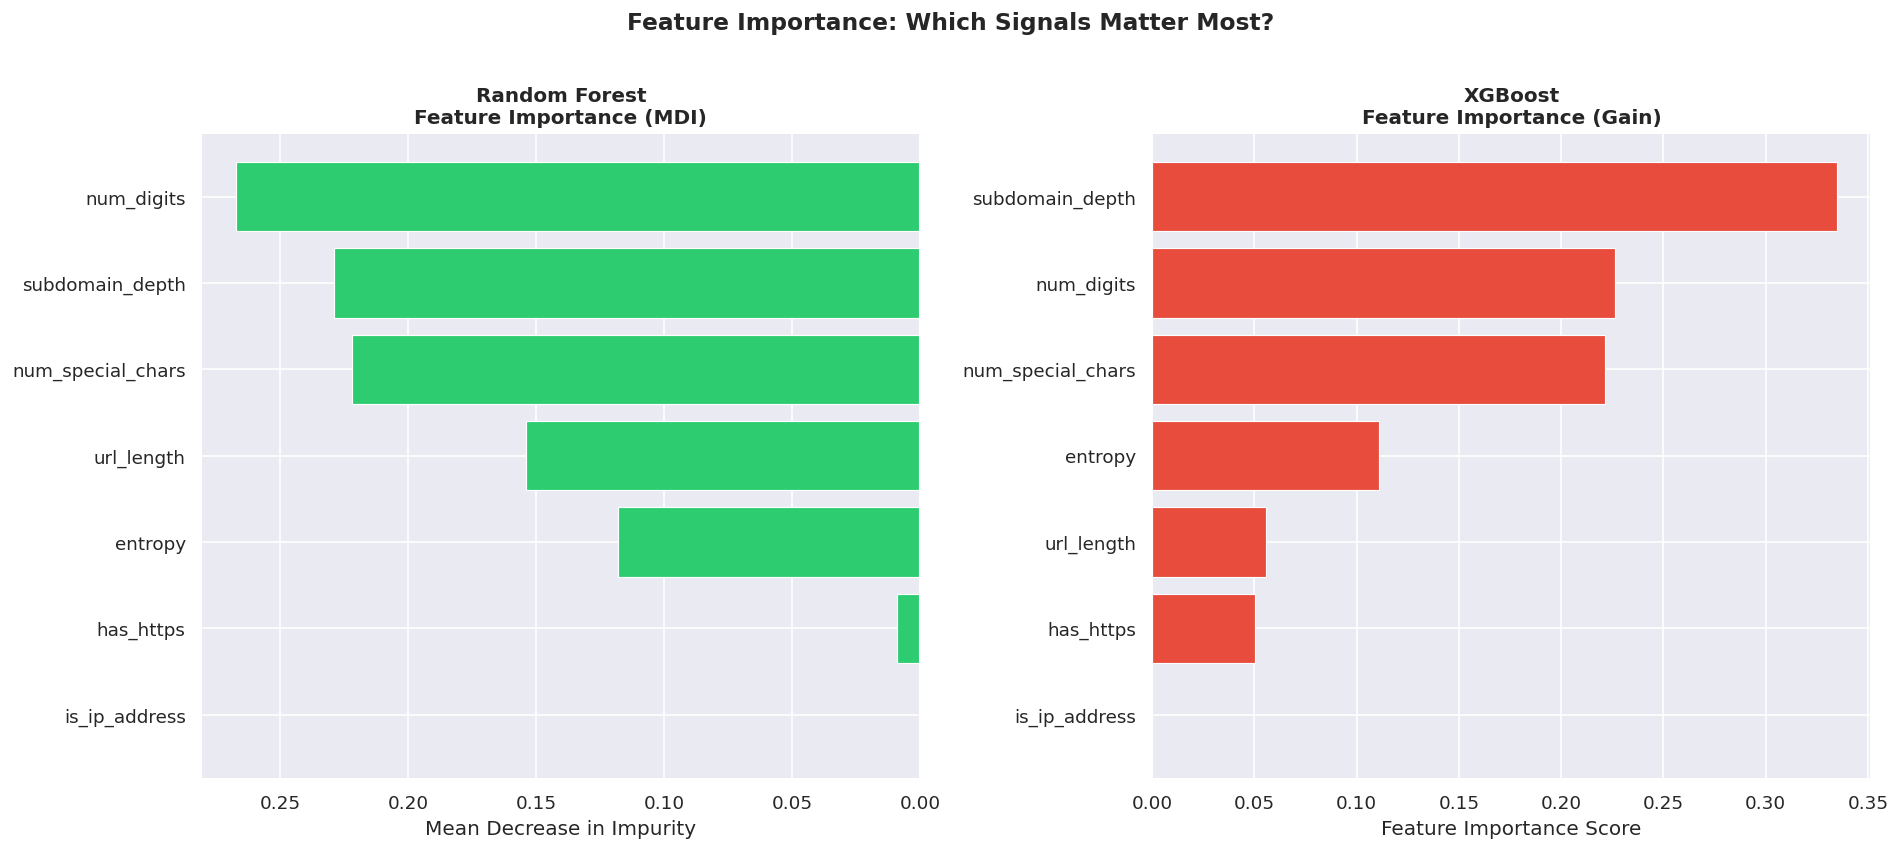


📋 Top 5 Features (Random Forest):
   num_digits               : 0.2675
   subdomain_depth          : 0.2292
   num_special_chars        : 0.2222
   url_length               : 0.1540
   entropy                  : 0.1179

📋 Top 5 Features (XGBoost):
   subdomain_depth          : 0.3347
   num_digits               : 0.2265
   num_special_chars        : 0.2216
   entropy                  : 0.1109
   url_length               : 0.0558


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

feature_names = feature_cols

# ── Random Forest Feature Importance ─────────────────────────────────────────
rf_importances = rf_model.feature_importances_
rf_sorted_idx = np.argsort(rf_importances)[::-1]

axes[0].barh([feature_names[i] for i in rf_sorted_idx[::-1]],
              rf_importances[rf_sorted_idx[::-1]],
              color="#2ecc71", edgecolor="white", linewidth=0.7)
axes[0].set_title("Random Forest\nFeature Importance (MDI)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Mean Decrease in Impurity")
axes[0].invert_xaxis()

# ── XGBoost Feature Importance ────────────────────────────────────────────────
xgb_importances = xgb_model.feature_importances_
xgb_sorted_idx = np.argsort(xgb_importances)[::-1]

axes[1].barh([feature_names[i] for i in xgb_sorted_idx[::-1]],
              xgb_importances[xgb_sorted_idx[::-1]],
              color="#e74c3c", edgecolor="white", linewidth=0.7)
axes[1].set_title("XGBoost\nFeature Importance (Gain)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Feature Importance Score")

plt.suptitle("Feature Importance: Which Signals Matter Most?",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n📋 Top 5 Features (Random Forest):")
for i in rf_sorted_idx[:5]:
    print(f"   {feature_names[i]:25s}: {rf_importances[i]:.4f}")

print("\n📋 Top 5 Features (XGBoost):")
for i in xgb_sorted_idx[:5]:
    print(f"   {feature_names[i]:25s}: {xgb_importances[i]:.4f}")

## 9️⃣ **Cross-Validation — Is Our Ensemble Stable?**

A single train/test split can be lucky or unlucky. **K-Fold Cross-Validation** gives us a more reliable estimate:

1. Split the training data into **K folds** (we use K=5)
2. Train on K-1 folds, validate on the remaining fold
3. Repeat K times, each time using a different fold for validation
4. **Average** the scores

If the cross-validation scores are consistent (low standard deviation), our model is **stable** and not just lucky on one split.

> ⚠️ Cross-validation on a full `VotingClassifier` is expensive. We'll do it on LightGBM (fastest model) to illustrate the concept.

🔁 Running 5-Fold Cross Validation on LightGBM...

Cross-Validation F1-Macro Scores: [0.9311 0.9313 0.9317 0.9323 0.9312]
Mean  : 0.9315
Std   : 0.0005  ← Low std = stable model
95% CI: [0.9306, 0.9324]


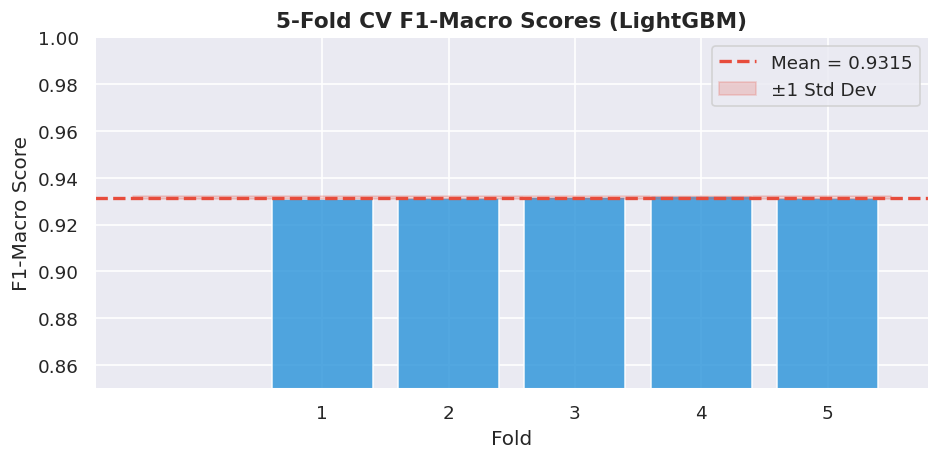

In [ ]:
# ── Stratified K-Fold Cross Validation ────────────────────────────────────────
# Stratified = maintains class proportions in each fold (important for imbalanced data!)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# We run CV on LightGBM (fastest) on the balanced training set
lgbm_cv = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
    random_state=SEED, n_jobs=-1, verbose=-1
)

print("🔁 Running 5-Fold Cross Validation on LightGBM...")
cv_scores = cross_val_score(lgbm_cv, X_train_bal, y_train_bal,
                             cv=cv, scoring="f1_macro", n_jobs=-1)

print(f"\nCross-Validation F1-Macro Scores: {cv_scores.round(4)}")
print(f"Mean  : {cv_scores.mean():.4f}")
print(f"Std   : {cv_scores.std():.4f}  ← Low std = stable model")
print(f"95% CI: [{cv_scores.mean() - 2*cv_scores.std():.4f}, {cv_scores.mean() + 2*cv_scores.std():.4f}]")

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color="#3498db", edgecolor="white", alpha=0.85)
ax.axhline(cv_scores.mean(), color="#e74c3c", linestyle="--", linewidth=2,
           label=f"Mean = {cv_scores.mean():.4f}")
ax.fill_between([-0.5, 5.5],
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.2, color="#e74c3c", label="±1 Std Dev")
ax.set_title("5-Fold CV F1-Macro Scores (LightGBM)", fontsize=13, fontweight="bold")
ax.set_xlabel("Fold")
ax.set_ylabel("F1-Macro Score")
ax.set_ylim(0.85, 1.0)
ax.set_xticks(range(1, 6))
ax.legend()
plt.tight_layout()
plt.show()

## 🏁 **Summary & Key Takeaways**

Congratulations — you've understood all of the necessary essentials!

### What We Did, Step by Step

| **Step** | **What we did** | **Why** |
|----------|----------------|---------|
| EDA | Visualized class distributions & feature separability | Understand the data before modelling |
| SMOTE | Synthetically balanced the training set | Prevent majority class from dominating |
| Random Forest | Trained an ensemble of independent trees | Strong, interpretable baseline |
| XGBoost | Trained sequential error-correcting trees | High accuracy via gradient boosting |
| CatBoost | Trained ordered boosting with symmetric trees | Handles categorical features, low bias |
| LightGBM | Trained leaf-wise histogram boosting | Fastest, great on large datasets |
| Soft Voting | Averaged probability outputs of all 4 models | Combines strengths, reduces individual model weaknesses |
| Evaluation | Classification report + confusion matrices | Understand per-class precision, recall, F1 |
| Cross-Validation | K-Fold CV on best individual model | Verify stability, not just lucky split |

### Why Soft Voting Worked Better

Each individual model has a different **inductive bias** — assumptions it bakes into its learning process. When we average their probability outputs:
- Mistakes that only one model makes get **diluted** by the other 3 models' correct answers
- Patterns that multiple models agree on get **amplified**
- The ensemble's decision boundary is **smoother** than any individual model

### What to Explore Next

- 🔬 **Hyperparameter tuning** with `optuna` or `RandomizedSearchCV`
- 🧠 **Stacking** (use model predictions as features for a meta-learner)
- 📊 **SHAP values** for per-prediction explainability
- 🌐 **Real threat feeds** (VirusTotal API, AlienVault OTX, AbuseIPDB)
- ⚙️ **Real-time scoring pipeline** with `MLflow` + a REST API
- ⭐ **More to come..**

---